# 개요

- 비선형 최소제곱에 특화된 $H$ 선택(Gauss-Newton)과, 그 해를 얼마나 믿을지를 $\lambda$ 로 다루는 방법(Levenberg-Marquardt).
- $\lambda D$ 가 정확히 무엇을 고쳐 주는지 — 그리고 **무엇은 고쳐주지 않는지** — 를 숫자로 확인한다.

# 1. Gauss-Newton과 Levenberg-Marquardt

- `Newton` $H = \nabla^{2}F$
	- 정확하지만 2차 미분이 필요하다
- `Gauss-Newton` $H = J^{T}J$
	- 1차 미분만으로 2차 정보를 얻는다. 대신 $H$ 가 특이할 수 있다
- `LM` $H = J^{T}J + \lambda D$
	- 특이해도 풀린다. 나빠지는 스텝은 거부한다

---
## 1.1. 2차항을 버릴 수 있는 이유

$F = \frac{1}{2}\|r(x)\|^{2}$ 의 gradient와 진짜 Hessian은 다음과 같다.

$$ g = J^{T}r, \qquad \nabla^{2}F = J^{T}J + \sum_{i} r_{i}\nabla^{2}r_{i} $$

- $J = \partial r / \partial x$: $(m, n)$

두 번째 항은 **residual에 비례한다**. 해 근처에서 $r_i$ 가 작으면 무시할 수 있고, 그러면 1차
미분만으로 2차 모델을 얻는다. 이것이 Gauss-Newton의 전부다.

$$
\boxed{
H_{GN} = J^{T}J, \qquad g = J^{T}r, \qquad H_{GN}\,\delta = -g
}
$$

거꾸로 말하면, residual이 큰 문제(모델이 틀렸거나 outlier가 섞였을 때)에서 GN이 잘 안 되는
것도 같은 이유다. 버린 항이 작지 않기 때문이다.

---
## 1.2. $J^{T}J$ 가 특이해지는 경우

$H_{GN} = J^{T}J$ 는 $J$ 가 열 full rank일 때만 가역이다. 실제로는 쉽게 깨진다.

- 두 매개변수가 같은 방향으로만 영향을 준다 (과매개화)
- 어떤 매개변수를 결정할 관측이 없다 (게이지 자유도)

이때 `np.linalg.solve` 는 `LinAlgError` 를 내거나, 더 나쁘게는 쓰레기 값을 돌려준다.

---
## 1.3. Levenberg-Marquardt

대각을 더해 강제로 양정부호로 만든다.

$$
\boxed{
\left(J^{T}J + \lambda D\right)\delta = -J^{T}r, \qquad D = \operatorname{diag}(J^{T}J)
}
$$

- $\lambda \to 0$: Gauss-Newton. 빠르지만 모델을 전부 믿는다
- $\lambda \to \infty$: $\delta \to -g / \lambda$, 아주 작은 gradient descent

$D$ 로 단위행렬 대신 $\operatorname{diag}(H)$ 를 쓰는 이유는 **매개변수마다 스케일이 다르기**
때문이다. $I$ 를 더하면 값이 큰 매개변수에만 damping이 걸린다.

---
## 1.4. Gain Ratio — 모델이 맞았는지 되묻기

$\lambda$ 를 고정하면 나빠지는 스텝도 그대로 받는다. 실제 감소량을 모델이 약속한 감소량으로
나눠 본다.

$$
\boxed{
\gamma = \frac{F(x) - F(x + \delta)}{m(0) - m(\delta)},
\qquad
m(0) - m(\delta) = \frac{1}{2}\delta^{T}\!\left(\lambda D\delta - g\right)
}
$$

- $\gamma$: gain ratio (robust loss $\rho$ 와 헷갈리지 않게 기호를 분리했다)

분모는 $\delta$ 와 $g$ 만으로 떨어지므로 따로 계산할 필요가 없다. 유도는 $(H + \lambda D)\delta = -g$
를 $m(0) - m(\delta) = -g^{T}\delta - \frac{1}{2}\delta^{T}H\delta$ 에 대입하면 바로 나온다.

- $\gamma > 0$: 받아들이고 $\lambda \leftarrow \lambda/3$
- $\gamma \le 0$: **스텝을 버리고** $\lambda \leftarrow 3\lambda$ 로 다시 푼다

즉,

> 모델이 약속한 만큼 실제로 내려갔는가? 아니면 한 걸음 물러서서 다시 묻는다

---
## 1.5. 전체 파이프라인

$$ \boxed{ r, J \rightarrow H = J^{T}J,\; g = J^{T}r \rightarrow (H + \lambda D)\delta = -g \rightarrow \gamma \rightarrow \{\text{수락}, \lambda/3\} \;|\; \{\text{거부}, 3\lambda\} } $$

```txt
        x_k
         |
      r, J  ------------------+
         |                    |
   H=J^TJ, g=J^Tr             |
         |                    |
   (H + lam D) d = -g   <-----+  lam 을 키워 다시 푼다
         |                       ^
      gain ratio                 |
      /        \                 |
  > 0          <= 0 -------------+
   |
 x <- x + d,  lam <- lam/3
```

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# numpy 2.x + Apple Accelerate 조합에서 matmul 이 부동소수점 상태 플래그를 잘못 남긴다.
# 결과값은 전부 정상이라(직접 대조해 확인했다) 이 조합에서만 나오는 잡음만 끈다.
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)


def pick_korean_font():
    """한글과 수학 마이너스(U+2212)를 **둘 다** 가진 폰트를 우선 고른다.

    로그 축 눈금은 $\mathdefault{10^{-13}}$ 로 그려지는데, mathtext 는 여기서 font.family 를
    쓴다. AppleGothic 계열에는 U+2212 가 없어서 지수의 마이너스가 네모로 깨진다 —
    한글은 멀쩡해서 알아채기 어렵다.
    """
    available = {f.name for f in font_manager.fontManager.ttflist}
    candidates = ("Arial Unicode MS", "Noto Sans CJK KR", "NanumGothic",
                  "Malgun Gothic", "Apple SD Gothic Neo", "AppleGothic")
    fallback = None
    for name in candidates:
        if name not in available:
            continue
        fallback = fallback or name
        try:
            path = font_manager.findfont(font_manager.FontProperties(family=name),
                                         fallback_to_default=False)
            if font_manager.get_font(path).get_char_index(0x2212):
                return name, True
        except Exception:
            continue
    return fallback, False


_font, _has_minus = pick_korean_font()
if _font:
    plt.rcParams["font.family"] = _font
    plt.rcParams["axes.unicode_minus"] = _has_minus   # 없으면 ASCII 하이픈으로 대체
    plt.rcParams["mathtext.fontset"] = "dejavusans"
print(f"font: {_font}  (U+2212 보유: {_has_minus})")

font: Arial Unicode MS  (U+2212 보유: True)


## 0. 샘플 데이터 생성하기

- $y = a e^{bt} + c$ 곡선 맞춤. $b$ 가 지수 안에 있어 강하게 비선형이다.
- 참값 `theta_true` 를 알고 있고, 초기값은 일부러 틀리게 준다.

In [2]:
import importlib
import problems
importlib.reload(problems)                 # 커널을 재시작하지 않아도 최신 버전을 반영
from problems import *

t, y, theta_true = make_curve_data(theta_true=(2.5, -0.7, 0.5), n=60, noise=0.03, seed=0)

theta_init = np.array([1.0, -0.5, 0.0])       # 적당히 틀린 초기값
theta_far = np.array([1.0, 0.2, 0.0])         # b 의 부호까지 틀린 초기값

print("theta_true :", theta_true)
print("theta_init :", theta_init, "  |오차| = %.3f" % np.linalg.norm(theta_init - theta_true))
print("theta_far  :", theta_far, "  |오차| = %.3f" % np.linalg.norm(theta_far - theta_true))

theta_true : [ 2.5 -0.7  0.5]
theta_init : [ 1.  -0.5  0. ]   |오차| = 1.594
theta_far  : [1.  0.2 0. ]   |오차| = 1.819


# 1. 데이터 시각화

초기 곡선이 참값에서 얼마나 떨어져 있는지 먼저 본다.

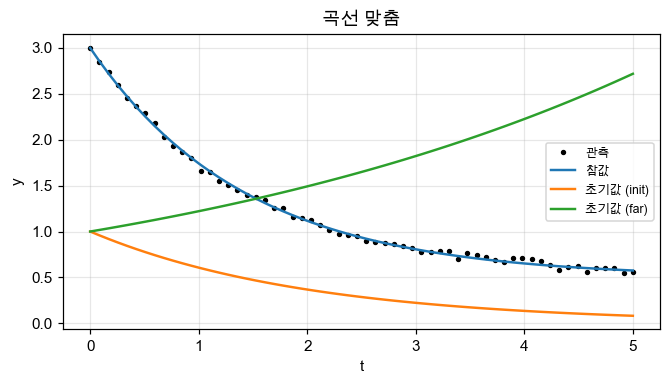

In [3]:
def show_fit(t, y, curves, labels, title="곡선 맞춤", mask=None):
    """관측과 여러 모델 곡선을 같은 축에 겹친다. before/after 를 이 함수 하나로 그린다."""
    plt.figure(figsize=(6.2, 3.6))
    if mask is None:
        plt.plot(t, y, "k.", ms=5, label="관측")
    else:
        plt.plot(t[~mask], y[~mask], "k.", ms=5, label="관측 (inlier)")
        plt.plot(t[mask], y[mask], "rx", ms=7, label="outlier")
    for theta, label in zip(curves, labels):
        plt.plot(t, curve_model(theta, t), lw=1.6, label=label)
    plt.xlabel("t"); plt.ylabel("y"); plt.title(title)
    plt.grid(True, alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()


show_fit(t, y, [theta_true, theta_init, theta_far],
         ["참값", "초기값 (init)", "초기값 (far)"])

# 2. Gauss-Newton과 LM

박스 수식 하나에 셀 하나씩.

In [4]:
# 1. 비용, 잔차, Jacobian - F = 1/2 ||r||^2
def cost_of(theta, t, y, residual=None):
    """F(theta). 잔차 함수를 바꿔 끼울 수 있게 인자로 받는다 (rank 결핍 실험에서 쓴다)."""
    r = (residual or curve_residual)(theta, t, y)
    return 0.5 * float(r @ r)

In [5]:
# 2. Gauss-Newton step - (J^T J) d = -g
def gn_step(theta, t, y, residual=curve_residual, jacobian=curve_jacobian):
    """H 를 그대로 푼다. 특이하면 LinAlgError 가 그대로 올라온다 — 감추지 않는다."""
    r = residual(theta, t, y)                    # (N,)
    J = jacobian(theta, t)                       # (N, P)
    H = J.T @ J                                  # (P, P)
    g = J.T @ r                                  # (P,)
    return np.linalg.solve(H, -g)                # 실패하면 예외

In [6]:
# 3. LM step + gain ratio - (H + lam D) d = -g, gamma = 실제감소 / 모델약속
def lm_step(theta, t, y, lam, residual=curve_residual, jacobian=curve_jacobian,
            max_tries=60):
    """스텝을 받아들일 때까지 lam 을 키우며 다시 푼다.

    반환: (새 theta, 새 lam, 수락 여부, gain ratio)
    """
    r = residual(theta, t, y)
    J = jacobian(theta, t)
    H = J.T @ J
    g = J.T @ r
    D = np.diag(np.maximum(np.diag(H), 1e-12))   # 0 대각은 damping 이 안 먹는다
    F = 0.5 * float(r @ r)

    for _ in range(max_tries):
        try:
            d = np.linalg.solve(H + lam * D, -g)
        except np.linalg.LinAlgError:
            lam *= 3.0
            continue
        F_new = cost_of(theta + d, t, y, residual)
        predicted = 0.5 * float(d @ (lam * D @ d - g))     # m(0) - m(delta)
        gamma = (F - F_new) / predicted if predicted > 0 else -1.0
        if gamma > 0:
            return theta + d, max(lam / 3.0, 1e-12), True, gamma
        lam *= 3.0                                          # 거부: 물러서서 다시
    return theta, lam, False, -1.0

## 2.1. 메인 루프

같은 초기값에서 GN과 LM을 나란히 돌린다. 번호 주석이 1.5절 파이프라인과 대응한다.

In [7]:
def run(kind, theta0, t, y, iters=60, tol=1e-12,
        residual=curve_residual, jacobian=curve_jacobian):
    """반환: dict(theta, status, cost_history, lam_history)"""
    theta = np.array(theta0, dtype=float)
    lam = 1e-3
    costs, lams = [], []

    for it in range(1, iters + 1):
        # 1. 현재 비용 기록
        F = cost_of(theta, t, y, residual)
        costs.append(F); lams.append(lam)
        if not np.isfinite(F) or F > 1e14:
            return dict(theta=theta, status="발산", costs=costs, lams=lams)

        # 2. gradient 가 0 이면 끝
        g = jacobian(theta, t).T @ residual(theta, t, y)
        if np.linalg.norm(g) < tol:
            return dict(theta=theta, status="수렴", costs=costs, lams=lams)

        # 3. 스텝
        if kind == "GN":
            try:
                theta = theta + gn_step(theta, t, y, residual, jacobian)
            except np.linalg.LinAlgError as e:
                return dict(theta=theta, status=f"LinAlgError ({e})", costs=costs, lams=lams)
        else:
            theta, lam, accepted, _ = lm_step(theta, t, y, lam, residual, jacobian)
            if not accepted:
                return dict(theta=theta, status="정체 (스텝 계속 거부)", costs=costs, lams=lams)

    return dict(theta=theta, status="반복 한계", costs=costs, lams=lams)


for kind in ("GN", "LM"):
    res = run(kind, theta_init, t, y)
    print(f"{kind}: {res['status']:12s} F={res['costs'][-1]:.4e}  "
          f"|theta-theta*|={np.linalg.norm(res['theta'] - theta_true):.4e}  "
          f"({len(res['costs'])} it)")

GN: 수렴           F=2.0426e-02  |theta-theta*|=2.8891e-02  (9 it)
LM: 수렴           F=2.0426e-02  |theta-theta*|=2.8891e-02  (9 it)


# 3. 검증

$\lambda D$ 가 실제로 무엇을 고치는지 세 가지로 나눠 확인한다.

## 3.1. $J$ 가 rank 결핍이면

$y = a e^{bt} + c + d$ 로 바꾸면 $c$ 와 $d$ 가 합으로만 나타난다. $J$ 의 마지막 두 열이 같아져
rank가 하나 모자라고, $H = J^{T}J$ 는 정확히 특이해진다. **이것이 $\lambda D$ 의 본래 일이다.**

In [8]:
theta_init4 = np.array([1.0, -0.5, 0.0, 0.0])
J4 = curve_jacobian_redundant(theta_init4, t)
print("rank(J) = %d / %d      cond(J^T J) = %.2e"
      % (np.linalg.matrix_rank(J4), J4.shape[1], np.linalg.cond(J4.T @ J4)))

results4 = {}
for kind in ("GN", "LM"):
    res = run(kind, theta_init4, t, y,
              residual=curve_residual_redundant, jacobian=curve_jacobian_redundant)
    results4[kind] = res
    # a, b 와 (c+d) 합만 비교한다 - c, d 는 개별로는 결정되지 않는다
    fitted = curve_model_redundant(res["theta"], t)
    curve_err = np.linalg.norm(fitted - curve_model(theta_true, t)) / np.sqrt(len(t))
    print(f"{kind}: {res['status']:34s} F={res['costs'][-1]:.4e}  곡선 RMS 오차={curve_err:.4e}")

rank(J) = 3 / 4      cond(J^T J) = 1.04e+34
GN: LinAlgError (Singular matrix)      F=2.5764e+01  곡선 RMS 오차=9.2575e-01
LM: 수렴                                 F=2.0426e-02  곡선 RMS 오차=7.0515e-03


## 3.2. 비용이 단조 감소하는가

gain ratio로 스텝을 거부하는 LM은 **구조적으로** 비용이 오를 수 없다. GN은 아무 보장이 없다.

In [9]:
runs = {kind: run(kind, theta_far, t, y, iters=40) for kind in ("GN", "LM")}

for kind, res in runs.items():
    c = np.array(res["costs"])
    rises = int(np.sum(np.diff(c) > 0))
    print(f"{kind}: 비용이 증가한 반복 {rises:2d}/{len(c)-1}회   "
          f"F: {c[0]:.3e} -> {c[-1]:.3e}   {res['status']}")

GN: 비용이 증가한 반복  3/12회   F: 4.536e+01 -> 2.043e-02   수렴
LM: 비용이 증가한 반복  0/39회   F: 4.536e+01 -> 2.204e+00   반복 한계


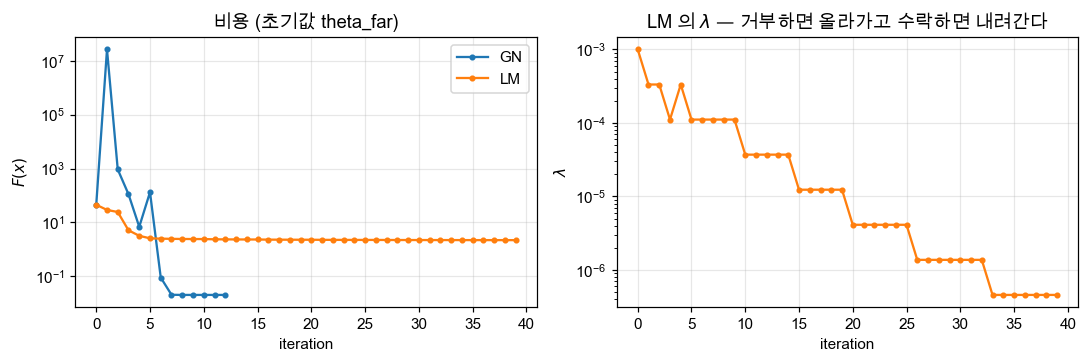

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

for kind, res in runs.items():
    axes[0].semilogy(np.maximum(res["costs"], 1e-20), "o-", ms=3, label=kind)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("$F(x)$")
axes[0].set_title("비용 (초기값 theta_far)"); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].semilogy(runs["LM"]["lams"], "o-", ms=3, color="tab:orange")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel(r"$\lambda$")
axes[1].set_title(r"LM 의 $\lambda$ — 거부하면 올라가고 수락하면 내려간다")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 3.3. 반례 — LM은 전역최소를 찾아주지 않는다

여기가 이 노트북에서 가장 오래 기억해야 할 부분이다. 위 `theta_far` 실행에서 **LM이 GN보다
나쁜 답에 멈췄다.** damping이 보장하는 것은 "터지지 않는다"와 "나빠지지 않는다"까지고,
어느 골짜기로 갈지는 초기값이 정한다.

스텝을 거부하는 성질이 오히려 발목을 잡는다 — 거칠게 움직이는 GN이 우연히 더 좋은 골짜기로
넘어가 버리는 일이 실제로 일어난다.

theta_far 에서 출발했을 때 참값과의 거리
  GN: |theta - theta*| =     0.0289   F = 2.0426e-02
  LM: |theta - theta*| =   115.2223   F = 2.2038e+00


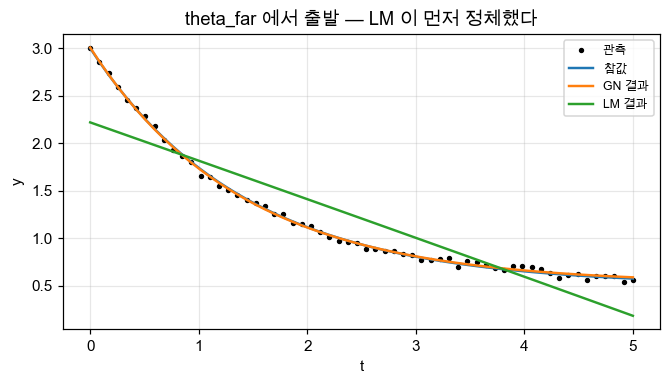

In [11]:
print("theta_far 에서 출발했을 때 참값과의 거리")
for kind, res in runs.items():
    print(f"  {kind}: |theta - theta*| = {np.linalg.norm(res['theta'] - theta_true):10.4f}   "
          f"F = {res['costs'][-1]:.4e}")

show_fit(t, y, [theta_true, runs["GN"]["theta"], runs["LM"]["theta"]],
         ["참값", "GN 결과", "LM 결과"], title="theta_far 에서 출발 — LM 이 먼저 정체했다")

## 3.4. 한계

- $\lambda$ 갱신 계수 3은 관습값이다. Madsen-Nielsen의 $\gamma$ 기반 연속 갱신이 더 정교하다.
- Dogleg(신뢰 반경을 직접 다루는 방식)은 다루지 않았다. LM은 $\lambda$ 를 바꿀 때마다 선형
  시스템을 다시 풀지만, Dogleg은 한 번만 풀면 된다는 차이가 있다.
- 여기서 본 "GN이 더 좋은 답에 도달"은 **이 초기값에서의 우연**이다. 일반적으로 기대할 성질이
  아니고, 반대 사례(3.1의 rank 결핍)가 훨씬 흔하다.